In [2]:
import plotly.graph_objects as go
import numpy as np

# 데이터 생성
x = np.linspace(0, 10, 100)
y = np.sin(x)

# 그래프 설정
fig = go.Figure(data=go.Scatter(
    x=x, y=y, 
    line=dict(shape='spline', smoothing=1.3), # 지오지브라 같은 부드러운 곡선
    name='Sine Wave'
))

# 레이아웃 (선택 사항: 더 지오지브라처럼 보이게)
fig.update_layout(
    template="plotly_white",
    xaxis_title="x 축",
    yaxis_title="y 축",
    xaxis=dict(showgrid=True, zeroline=True),
    yaxis=dict(showgrid=True, zeroline=True)
)

fig.show()

In [3]:
import plotly.graph_objects as go
import numpy as np

# 1. 데이터 생성 (일부러 점을 적게 줌: 15개)
# -3부터 2까지 15개의 점만 생성합니다.
x_data = np.linspace(-3, 2, 15)
# 3차 함수 식: y = (x+2) * x * (x-1)
y_data = (x_data + 2) * x_data * (x_data - 1)

# 2. 그래프 객체 생성
fig = go.Figure()

# 3. 3차 함수 곡선 추가
fig.add_trace(go.Scatter(
    x=x_data, 
    y=y_data, 
    mode='lines+markers', # 점과 선을 모두 표시 (스플라인 효과 확인용)
    # 핵심 설정: shape='spline'으로 단순 직선 연결이 아닌 수학적 곡선 구현
    line=dict(color='#2ca02c', width=3, shape='spline', smoothing=1.3), 
    marker=dict(size=8, color='black', symbol='circle-open'), # 데이터 포인트 표시
    name='y = (x+2)x(x-1)'
))

# 4. 지오지브라 스타일 레이아웃 설정 (격자, 축 강조)
fig.update_layout(
    title='Smooth Cubic Function: $y = (x+2)x(x-1)$ (GeoGebra Style)',
    xaxis=dict(
        title='x axis',
        showgrid=True, gridwidth=1, gridcolor='LightGrey', # 격자
        zeroline=True, zerolinewidth=2, zerolinecolor='Black', # x축 강조
        dtick=1 # 격자 간격
    ),
    yaxis=dict(
        title='y axis',
        showgrid=True, gridwidth=1, gridcolor='LightGrey',
        zeroline=True, zerolinewidth=2, zerolinecolor='Black', # y축 강조
        dtick=1
    ),
    plot_bgcolor='white', # 배경을 하얗게
    width=800, height=600,
    margin=dict(l=40, r=40, t=60, b=40),
    #hovermode="x unified" # 마우스를 올렸을 때 x값에 대한 y값을 한데 보여줌
)

# 5. 그래프 출력 (코랩/VS Code 셀 바로 아래)
fig.show()

In [12]:
import plotly.graph_objects as go
import numpy as np

class MathGrapher:
    def __init__(self, func, x_range=(-5, 5), title="Perfect Coordinate System"):
        self.x_start, self.x_end = x_range
        
        # 1. 데이터 생성
        x = np.linspace(self.x_start, self.x_end, 300)
        y = func(x)
        
        # 2. 그래프 객체 생성
        self.fig = go.Figure()
        
        # 3. 곡선 추가
        self.fig.add_trace(go.Scatter(
            x=x, y=y,
            mode='lines',
            line=dict(color='#2ca02c', width=3, shape='spline', smoothing=1.3),
            hoverinfo='x+y'
        ))

        # 4. 레이아웃 설정 (숫자를 축 안쪽으로 이동)
        self.fig.update_layout(
            title=title,
            template="plotly_white",
            xaxis=dict(
                range=[self.x_start, self.x_end],
                showgrid=True, gridcolor='LightGrey',
                zeroline=True, zerolinewidth=2, zerolinecolor='Black',
                
                # --- 숫자를 축(0점) 근처로 보내는 핵심 설정 ---
                anchor="free",
                position=0,       # y=0 지점에 x축 고정
                tickmode='linear', dtick=1,
                tickfont=dict(size=10, color='black'),
                ticklabelposition="inside top", # 숫자를 축 선 안쪽(위쪽)으로
                showticklabels=True,
            ),
            yaxis=dict(
                # y축 범위는 데이터에 따라 자동 조절되지만 0을 포함하도록 설정
                showgrid=True, gridcolor='LightGrey',
                zeroline=True, zerolinewidth=2, zerolinecolor='Black',
                
                # --- 숫자를 축(0점) 근처로 보내는 핵심 설정 ---
                anchor="free",
                position=0,       # x=0 지점에 y축 고정
                scaleanchor="x", scaleratio=1,
                tickmode='linear', dtick=1,
                tickfont=dict(size=10, color='black'),
                ticklabelposition="inside right", # 숫자를 축 선 안쪽(오른쪽)으로
                showticklabels=True,
            ),
            width=700, height=700,
            showlegend=False,
            margin=dict(l=50, r=50, t=80, b=50)
        )

    def show(self):
        self.fig.show()

# --- 실행 ---
graph = MathGrapher(lambda x: (x+2)*x*(x-1), (-3, 2))
graph.show()

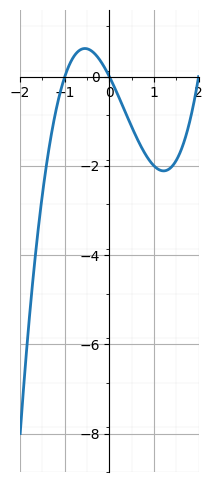

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def auto_tick_step(vmin, vmax):
    span = abs(vmax - vmin)

    if span <= 10:
        return 1
    elif span <= 20:
        return 2
    elif span <= 50:
        return 5
    elif span <= 100:
        return 10
    else:
        return 20

def geogebra_style(func, x_range=(-5, 5), y_range=None):
    x = np.linspace(x_range[0], x_range[1], 1000)
    y = func(x)

    # y 범위 자동 설정
    if y_range is None:
        y_margin = (y.max() - y.min()) * 0.1
        y_range = (y.min() - y_margin, y.max() + y_margin)

    fig, ax = plt.subplots(figsize=(6, 6))

    # ===== 그래프 =====
    ax.plot(x, y, linewidth=2)

    # ===== 축을 원점으로 =====
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # ===== 자동 눈금 간격 =====
    x_step = auto_tick_step(*x_range)
    y_step = auto_tick_step(*y_range)

    # 큰 눈금
    ax.set_xticks(np.arange(int(x_range[0]), int(x_range[1]) + 1, x_step))
    ax.set_yticks(np.arange(int(y_range[0]), int(y_range[1]) + 1, y_step))

    # 작은 눈금 (큰 눈금의 절반)
    ax.set_xticks(np.arange(x_range[0], x_range[1], x_step/2), minor=True)
    ax.set_yticks(np.arange(y_range[0], y_range[1], y_step/2), minor=True)

    # ===== 격자 =====
    ax.grid(which='major', linewidth=0.8)
    ax.grid(which='minor', linewidth=0.3, alpha=0.3)

    # ===== 비율 =====
    ax.set_aspect('equal', adjustable='box')

    # ===== 범위 =====
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)

    plt.show()


# 실행
geogebra_style(lambda x: (x+1) * x * (x-2), (-2, 2))